In [ ]:
import pandas as pd
import numpy as np

import csv

datfile = "./CALexp3.csv"
labelfile = "./KMTRICKS2MORPHO.tsv"

datorg = pd.read_csv(datfile,index_col=0)
dat = datorg.T
dat.columns = dat.columns.astype(str)
lab = pd.read_csv(labelfile, header=None, sep='\t')
labnames = lab.values[:,0:2]


dict0 = {'Wild':1, 'Cabbage':2,'acephala':3,'Broccoli': 4,'Cauliflower': 5}
dict5 = {'Broccoli': 0,'Cauliflower': 1}
dict4 = {'Broccoli': 1,'Cauliflower': 0}
dict45 = {'Broccoli': 1,'Cauliflower': 1}
dict123 = {'Wild':1, 'Cabbage':1,'acephala':1,'Broccoli': 0,'Cauliflower': 0}
default_value=0

ynames = dat.axes[0].values
name5 = {}
name4 = {}
name45 = {}
name123 = {}
name = {}
for i in range(len(labnames)):
    name4[labnames[i,0]] = dict4.get(labnames[i,1], default_value) 
    name5[labnames[i,0]] = dict5.get(labnames[i,1], default_value) 
    name45[labnames[i,0]] = dict45.get(labnames[i,1], default_value) 
    name123[labnames[i,0]] = dict123.get(labnames[i,1], default_value) 
    name[labnames[i,0]] = dict0.get(labnames[i,1], default_value) 

y4 = np.array(list(map(lambda x: name4[x],ynames)))
y5 = np.array(list(map(lambda x: name5[x],ynames)))
y45 = np.array(list(map(lambda x: name45[x],ynames)))
y123 = np.array(list(map(lambda x: name123[x],ynames)))
y = np.array(list(map(lambda x: name[x],ynames)))

dat['Label5'] = y5
dat['Label4'] = y4
dat['Label45'] = y45
dat['Label123'] = y123
dat['Label0'] = y


CALkmer = []
#with open("CALexp_selected_feature_set.csv", newline="", encoding="utf-8") as csvfile:
with open("FeatureSubset50.csv", newline="", encoding="utf-8") as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        CALkmer +=(row)
#CALkmer=list(map(int,CALkmer))
labellist = ['Label5','Label4','Label45','Label123','Label0']
dat = dat[CALkmer+labellist]



cornerdat = dat[list(map(str,[144,249,1973,1981,2655,8040,9299,3736,3777,5201]))+['Label0']]

#cornerdat.to_csv('cornerdat.csv')
#print(cornerdat.columns)
#cornerdat


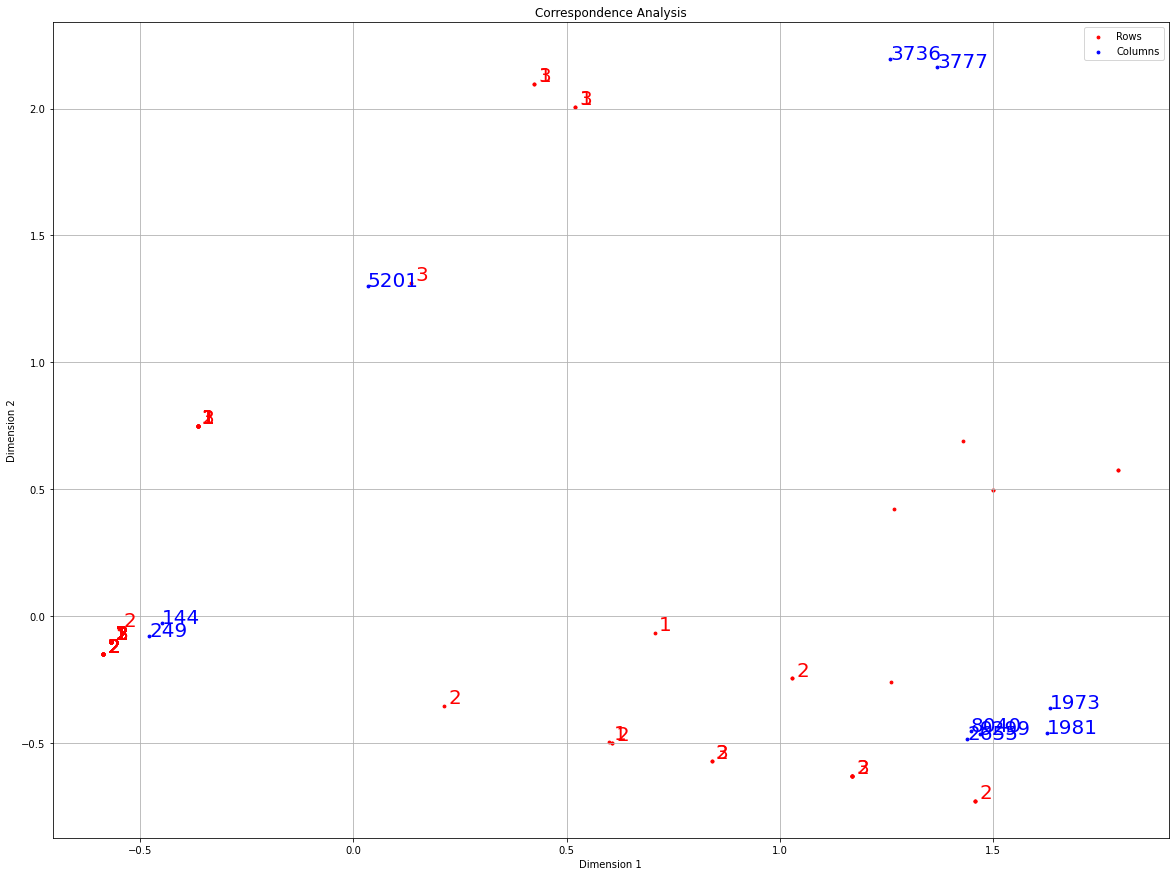

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import prince
## CORRESPONDENCE ANALYSIS

def corrheatmap():
    corrmat = cornerdat.corr()
    plt.figure(figsize=(16, 12)) # Adjust figure size if needed
    sns.heatmap(
        corrmat,
        annot=True,
        cmap='coolwarm', # A common colormap for correlation heatmaps
        fmt=".2f", # Format annotations to two decimal places
        square=True # Ensure cells are square
    )
    plt.title('Selected Features Pairwise Correlation Heatmap: CAULI')
    plt.show()
    

cdat = cornerdat.drop('Label0',axis=1)


ca = prince.CA(n_components=2)
ca = ca.fit(cdat)
# Extract row and column coordinates
row_coords = ca.row_coordinates(cdat)
col_coords = ca.column_coordinates(cdat)


# Plotting the results
plt.figure(figsize=(20, 15))
plt.scatter(row_coords[0], row_coords[1], c='red', label='Rows',s=8)
plt.scatter(col_coords[0], col_coords[1], c='blue', label='Columns',s=8)



# Adding labels
for i, txt in enumerate(cornerdat['Label0']): 
    if txt<4:
        plt.annotate(txt, (row_coords[0][i]+0.01, row_coords[1][i]+0.01), color='red',size=20)


for i, txt in enumerate(cdat.columns):
    plt.annotate(txt, (col_coords[0][txt], col_coords[1][txt]), color='blue',size=20)

plt.title('Correspondence Analysis')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.grid()
plt.show()

(53, 2)


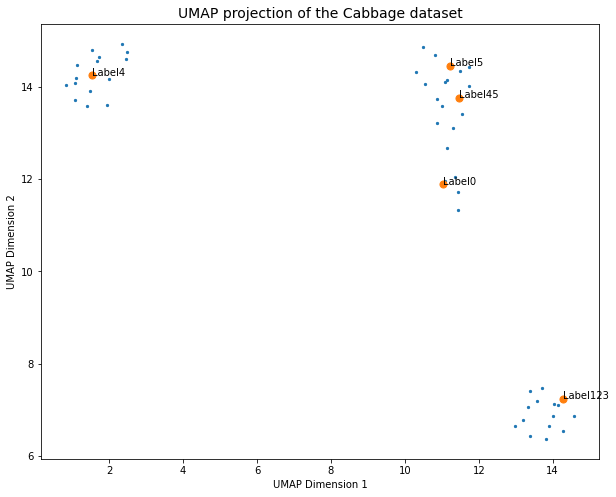

In [29]:
import numpy as np
import umap
import sklearn.datasets
import matplotlib.pyplot as plt

X = dat.T

reducer = umap.UMAP(random_state=42, n_jobs=1) # Set random_state for reproducibility
embedding = reducer.fit_transform(X)
print(embedding.shape)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()
scatter = ax.scatter(
    embedding[:48, 0],
    embedding[:48, 1],
    #c=y, # Color points by their target label (digit value)
    #cmap='Accent', # Use a visually distinct colormap
    s=5 # Adjust point size for better visibility, especially with large datasets
)
scatter = ax.scatter(
    embedding[48:, 0],
    embedding[48:, 1],

    s=50 # Adjust point size for better visibility, especially with large datasets
)
n, m = X.shape
for i  in range(48,n):
    ax.annotate(dat.columns[i], (embedding[i,0], embedding[i,1]))

# Add a color bar and set ticks to correspond to digit labels (0-9)
#plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
plt.title('UMAP projection of the Cabbage dataset', fontsize=14)
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.show()


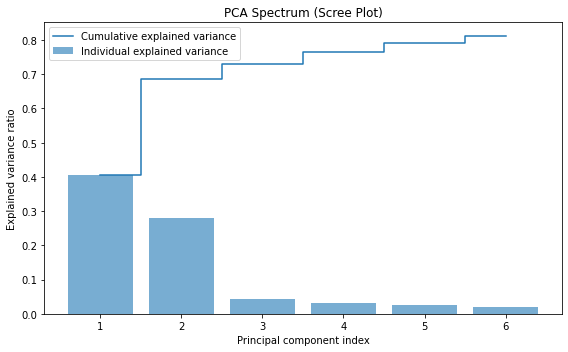

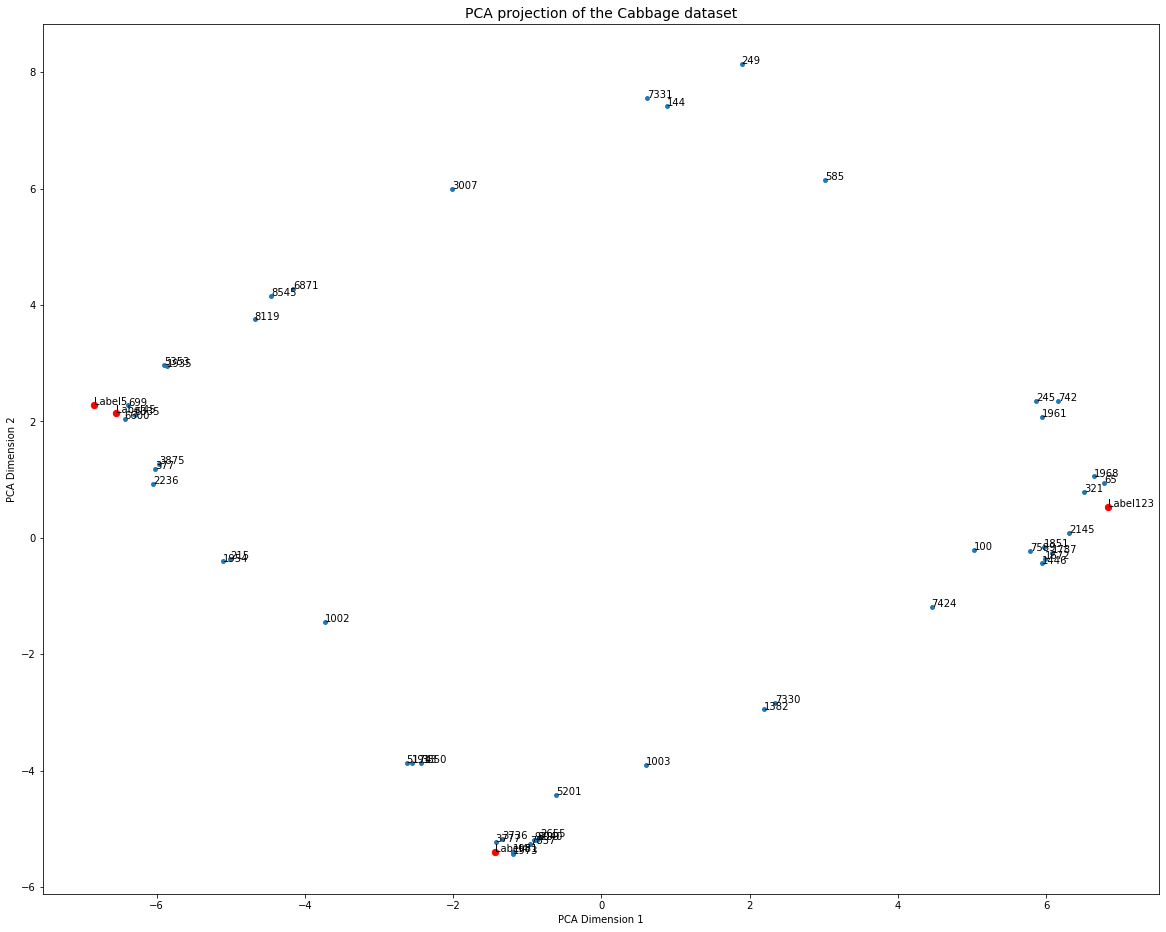

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
#from mpl_toolkits.mplot3d import Axes3D

# Sample data (replace with your actual data, X)
# For example, using the Iris dataset


X = dat.drop(labellist,axis=1).T

# Label y5 is for cauliflower
# labels for broccoli y4, and the rest is y123 


# 2. Fit the PCA model
# You can set n_components to the total number of features to get all components' variance
pca = PCA(n_components=6)
pca.fit(X)

embedding= pca.transform(dat.drop('Label0',axis=1).T)
#embedding= pca.transform(X) 



# 3. Access the explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

def spectrumplot():
    # 4. Plot the "spectrum" (scree plot)
    plt.figure(figsize=(8, 5))
    plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.6, label='Individual explained variance')
    plt.step(range(1, len(explained_variance_ratio) + 1), np.cumsum(explained_variance_ratio), where='mid', label='Cumulative explained variance')
    plt.ylabel('Explained variance ratio')
    plt.xlabel('Principal component index')
    plt.title('PCA Spectrum (Scree Plot)')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()
spectrumplot()


fig = plt.figure(figsize=(20, 16))
ax = fig.add_subplot()
scatter = ax.scatter(
    embedding[:48, 0],
    embedding[:48, 1],
    
    #c=y, # Color points by their target label (digit value)
    cmap='Accent', # Use a visually distinct colormap
    s=15 # Adjust point size for better visibility, especially with large datasets
)
n, m = embedding.shape 
m
#collist = []
#for i in range(n):
#    if 10*embedding[i,0]+7*embedding[i,1]<= -45 and embedding[i,0]<-3.5:
#        scatter = ax.scatter(embedding[i,0],embedding[i,1],s=20)
#        collist += [datorg.index.tolist()[i]]

#print(collist)
scatter = ax.scatter(
    embedding[48:, 0],
    embedding[48:, 1],
    c='red',
    s=40 # Adjust point size for better visibility, especially with large datasets
)


for i  in range(0,n): 
    ax.annotate(dat.columns[i], (embedding[i,0], embedding[i,1]))
    #ax.text(embedding[i,0], embedding[i,1],embedding[i,2], dat.columns[i], size=10)

# Add a color bar and set ticks to correspond to digit labels (0-9)
#plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
plt.title('PCA projection of the Cabbage dataset', fontsize=14)
plt.xlabel('PCA Dimension 1')
plt.ylabel('PCA Dimension 2')
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
import matplotlib.pyplot as plt


dtree = DecisionTreeClassifier(max_depth=2, random_state=42,min_samples_leaf=7)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = dat.drop('Label',axis=1)

count =0
while True:
    scores = cross_val_score(dtree, X, y, cv=skf, scoring='accuracy')
    if scores.mean()>0.9:
        # build the model
        dtree.fit(X,y)
        print(export_text(dtree,feature_names=X.columns))
        
        if X.shape[1] <=1:
            break
        plt.figure(figsize=(15, 10)) # Adjust the figure size for better visibility
        plot_tree(dtree, 
          feature_names=X.columns,  # Use actual feature names
          #class_names=dat.target_names,    # Use actual class names
          filled=True,                      # Color the nodes by majority class
          rounded=True,                     # Use rounded node boxes
          precision=2,                      # Decimal precision for floats
          fontsize=10)                      # Adjust font size
        plt.show() # Display the plot (mandatory in some environments like Windows)
        count +=1 
        
        idx = dtree.tree_.feature # set of features - remove to 
        X = X.drop(X.columns[idx],axis=1)
    else: break
print(f'Totally {count} number of trees generated')




In [ ]:
#print(dat.head())
#print(dat.shape)
# selecting the most complementary features to an existing one
def mostcomp(km : int):
    corr = dat[km].corr(dat['Label'])
    sign = np.sign(corr)
    #print(corr)
    mask = (dat[km] == dat['Label']) if sign <0 else (dat[km] != dat['Label'])
    df = dat.loc[mask]
    #print(df.head())
    print(df.shape[0],sum(df['Label']))
    corr2label = df.corrwith(df['Label'])
    c2la = abs(corr2label)
    # To find the feature with the highest absolute correlation:
    topk_indices = list(df.columns[c2la>=0.9])
    print(f'Best complement to {km} are: {topk_indices}')


mostcomp(6600)
mostcomp(321)
mostcomp(699)
mostcomp(65)
mostcomp(1851)
mostcomp(1935)
mostcomp(2236)
mostcomp(1787)
mostcomp(3850)
mostcomp(3875)


In [ ]:
# Visualizing selected k-mers correlations

import seaborn as sns
import matplotlib.pyplot as plt

gr1 = [3875, 7863, 7874,3319,7859,7864]
gr2 = [65, 104, 193, 1141, 1185, 2054, 2382, 2915, 3096, 8547, 8991]
gr = ['Label']+gr1+gr2
corrmat = dat[gr].corr()
plt.figure(figsize=(16, 12)) # Adjust figure size if needed
sns.heatmap(
    corrmat,
    annot=True,
    cmap='coolwarm', # A common colormap for correlation heatmaps
    fmt=".2f", # Format annotations to two decimal places
    square=True # Ensure cells are square
)
plt.title('Selected Features Pairwise Correlation Heatmap: CAULI+BROCC')
plt.show()

dat[gr].to_csv('./Exp3_extract1.csv')

gr1 = [3875, 7863, 7874]
gr2 = [1463, 3476, 4991]
gr = ['Label']+gr1+gr2
corrmat = dat[gr].corr()
plt.figure(figsize=(16, 12)) # Adjust figure size if needed
sns.heatmap(
    corrmat,
    annot=True,
    cmap='coolwarm', # A common colormap for correlation heatmaps
    fmt=".2f", # Format annotations to two decimal places
    square=True # Ensure cells are square
)
plt.title('Selected Features Pairwise Correlation Heatmap: CAULI vs THE REST')
plt.show()

dat[gr].to_csv('./Exp3_extract2.csv')